Volume 2 (Tissue) -> Mean de/dl: 183.2876
Volume 3 (Tumor) -> Mean de/dl: 708.9596
Volume 6 (Detector3) -> Mean de/dl: 3231.9215


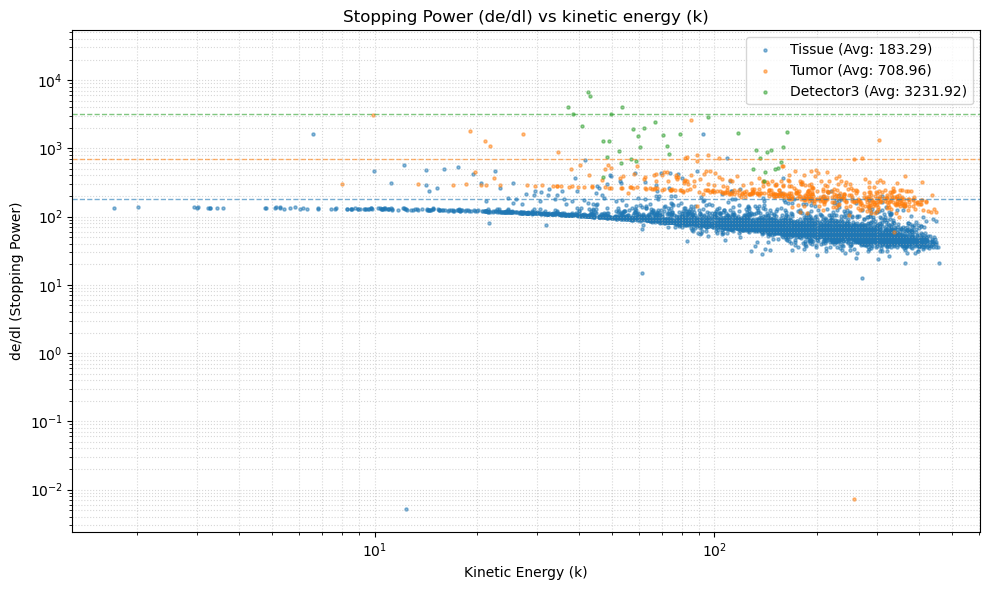

In [3]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

file_path = "tumor.root"

vlm_labels = {
    2: "Tissue",
    3: "Tumor",
    4: "Detector1",
    5: "Detector2",
    6: "Detector3"
}

with uproot.open(file_path) as f:
    tree = f["t"]
    
    # Extracting de, dl, vlm, and momentum (p)
    # Using library="np" and flattening the arrays
    de = np.concatenate(tree["de"].array(library="np")).ravel()
    dl = np.concatenate(tree["dl"].array(library="np")).ravel()
    vlm = np.concatenate(tree["vlm"].array(library="np")).ravel()
    k = np.concatenate(tree["k"].array(library="np")).ravel() 

plt.figure(figsize=(10, 6))

# Volumes of interest for your simulation
for v in [2, 3, 6]:
    # Filter for the specific volume and ensure no division by zero
    mask = (vlm == v) & (dl > 0) & (de > 0)
    
    k_v = k[mask]
    dedl_v = de[mask] / dl[mask]

    # Calculate the Average value
    avg_dedl = np.mean(dedl_v)
    print(f"Volume {v} ({vlm_labels[v]}) -> Mean de/dl: {avg_dedl:.4f}")

    # Plotting de/dl vs k
    # The label includes the average for the legend
    scatter = plt.scatter(k_v, dedl_v, s=5, alpha=0.5, 
                          label=f"{vlm_labels[v]} (Avg: {avg_dedl:.2f})")
    
    # Add a horizontal dashed line for the average
    color = scatter.get_facecolor()[0]
    plt.axhline(y=avg_dedl, color=color, linestyle='--', alpha=0.6, linewidth=1)

plt.yscale("log")
plt.xscale("log") # Momentum vs energy loss is often clearer on a log-log scale
plt.xlabel("Kinetic Energy (k)")
plt.ylabel("de/dl (Stopping Power)")
plt.title("Stopping Power (de/dl) vs kinetic energy (k)")
plt.legend(loc='upper right')
plt.grid(True, which="both", linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()